[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter8_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 8: Backtesting and Evaluating Risk Forecasts

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and number of Lecture 8:
- S&P 500, BET and Bitcoin daily closes (course repository, `data/market`); EUR/RON: BNR reference rate;
- rolling one-day-ahead VaR and ES forecasts of six models (HS, Normal, Student-t, GARCH-t, FHS, GARCH-EVT);
- VaR tests, ES tests, scoring functions, model comparison and conformal VaR.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import sys
import subprocess
try:
    import arch  # GARCH estimation
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
import pickle
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats, optimize
from numpy.lib.stride_tricks import sliding_window_view
import warnings
warnings.filterwarnings('ignore')

## Data and forecasting engine

- Loss $L_t=-r_t$, $r_t=\ln P_t-\ln P_{t-1}$, each series on its own calendar.
- Window of 1000 observations; GARCH, Student-t and EVT parameters re-estimated every 20 days.
- The first run estimates the forecasts of all four markets (a few minutes).

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

# nume -> (simbol, data de start); indici/cripto: pretul de inchidere
SOURCES = {
    'sp500':  ('GSPC.INDX', '1990-01-01'),
    'bet':    ('BET', '1997-09-19'),
    'btc':    ('BTC-USD.CC', '2014-09-17'),
    'eurron': ('REF:EUR', '2005-07-01'),        # cursul de referinta BNR, de la introducerea leului nou
}
LABELS = {'sp500': 'S&P 500', 'bet': 'BET', 'btc': 'Bitcoin', 'eurron': 'EUR/RON'}
ASSETS = list(SOURCES)

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Cursul oficial de referinta RON publicat de BNR (arhive XML anuale)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_price(name):
    """Seria de preturi (inchidere) a activului."""
    symbol, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    p = read_market(symbol)['close'].loc[start:]
    return p[p > 0].dropna()


def load_returns(name):
    """Randamente log zilnice pe calendarul propriu al seriei."""
    return np.log(load_price(name)).diff().dropna()


# =============================================================================
# PROGNOZE VaR / ES PE FEREASTRA MOBILA (o zi inainte)
# =============================================================================
W = 1000                       # fereastra de estimare (observatii)
REFIT = 20                     # parametrii GARCH / t / EVT se reestimeaza la fiecare 20 de zile
LEVELS = (0.01, 0.025, 0.05)   # probabilitati de coada: VaR 1%, VaR 2.5%, VaR 5%
A_ES = 0.025                   # ES 2.5% (FRTB)
K_TAIL = int(np.ceil(A_ES * W))   # numarul de statistici de ordine din coada (simularea Z2)
MODELS = ['HS', 'Normal', 'Student-t', 'GARCH-t', 'FHS', 'GARCH-EVT']
EVAL_FROM = '2007-01-01'       # prima zi posibila de evaluare
EVT_Q = 0.90                   # pragul POT: cuantila 90% a pierderilor standardizate


def t_std_q(nu, a):
    """Cuantila 1-a a distributiei Student-t standardizate (dispersie 1)."""
    return stats.t.ppf(1 - a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """ES la nivelul 1-a al distributiei Student-t standardizate (dispersie 1)."""
    q = stats.t.ppf(1 - a, nu)
    return stats.t.pdf(q, nu) / a * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


def garch_fit(x, prev=None):
    """GARCH(1,1) cu inovatii Student-t, prin verosimilitate maxima; parametri in unitati zecimale.
    Seria este rescalata la dispersie unitara pentru stabilitate numerica; daca optimizarea esueaza,
    se pastreaza parametrii estimati anterior."""
    from arch import arch_model
    c = 1 / x.std()
    res = arch_model(c * x, mean='Constant', vol='GARCH', p=1, q=1, dist='t',
                     rescale=False).fit(disp='off', show_warning=False)
    mu, om, a, b, nu = res.params.values
    ok = res.convergence_flag == 0 and abs(mu) < 1 and a + b < 1 and om > 0
    if not ok and prev is not None:
        return prev
    return mu / c, om / c ** 2, a, b, nu


def garch_filter(x, mu, om, a, b, s2_0):
    """Dispersia conditionata: s2[t] foloseste doar x[:t]; ultimul element este prognoza."""
    e2 = (x - mu) ** 2
    s2 = np.empty(len(x) + 1)
    s2[0] = s2_0
    for t in range(len(x)):
        s2[t + 1] = om + a * e2[t] + b * s2[t]
    return s2


def gpd_tail(y, a_list, q=EVT_Q):
    """EVT (POT): GPD pe excedentele pierderilor standardizate peste cuantila q; VaR/ES la nivelurile 1-a."""
    u = np.quantile(y, q)
    exc = y[y > u] - u
    xi, _, beta = stats.genpareto.fit(exc, floc=0)
    pu = len(exc) / len(y)
    var = {a: u + beta / xi * ((a / pu) ** (-xi) - 1) for a in a_list}
    es = {a: (var[a] + beta - xi * u) / (1 - xi) for a in a_list}
    return dict(u=u, xi=xi, beta=beta, pu=pu, var=var, es=es)


def gpd_cdf(y, g, emp):
    """Functia de repartitie EVT: empirica sub prag, GPD deasupra pragului."""
    if y <= g['u']:
        return np.mean(emp <= y)
    base = 1 + g['xi'] * (y - g['u']) / g['beta']
    return 1.0 if base <= 0 else 1 - g['pu'] * base ** (-1 / g['xi'])


def rolling_forecasts(r, eval_from=EVAL_FROM, w=W, refit=REFIT):
    """Prognoze VaR (LEVELS) si ES (A_ES) la o zi pentru pierderea L = -r, cu toate modelele.

    Rezultat: dict model -> DataFrame (index = ziua prognozata) cu coloanele
    VaR1, VaR2.5, VaR5, ES2.5, ES1, pit (F(L_t)), scale, mu, plus informatii pentru simularea cozii."""
    r = r.dropna()
    L = -r.values
    idx = r.index
    start = max(w, int(np.searchsorted(idx, pd.Timestamp(eval_from))))
    T = len(r) - start
    days = idx[start:]
    out = {m: {k: np.full(T, np.nan) for k in ['VaR1', 'VaR2.5', 'VaR5', 'ES2.5', 'ES1', 'pit', 'scale', 'mu', 'nu',
                                               'u', 'xi', 'beta', 'pu']} for m in MODELS}
    tails = {m: np.full((T, K_TAIL), np.nan) for m in ('HS', 'FHS')}
    lev = {0.01: 'VaR1', 0.025: 'VaR2.5', 0.05: 'VaR5'}
    Lcur = L[start:]

    # --- HS si Normal: vectorizat pe ferestre
    win = sliding_window_view(L[:-1], w)[start - w:]          # fereastra pentru ziua t: L[t-w:t]
    srt = np.sort(win, axis=1)
    o = out['HS']
    for a, k in lev.items():
        o[k] = np.quantile(win, 1 - a, axis=1)
    for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
        v = np.quantile(win, 1 - a, axis=1)
        o[k] = np.nanmean(np.where(win >= v[:, None], win, np.nan), axis=1)
    o['pit'] = (np.sum(win < Lcur[:, None], axis=1) + 0.5 * np.sum(win == Lcur[:, None], axis=1)) / w
    o['scale'] = win.std(axis=1, ddof=1)
    o['mu'] = np.zeros(T)
    tails['HS'] = srt[:, -K_TAIL:]
    mu_w, sd_w = -win.mean(axis=1), win.std(axis=1, ddof=1)     # medie a randamentelor, abatere standard
    o = out['Normal']
    for a, k in lev.items():
        o[k] = -mu_w + sd_w * stats.norm.ppf(1 - a)
    for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
        o[k] = -mu_w + sd_w * stats.norm.pdf(stats.norm.ppf(1 - a)) / a
    o['pit'] = stats.norm.cdf((Lcur + mu_w) / sd_w)
    o['scale'], o['mu'] = sd_w, mu_w

    # --- modele reestimate la fiecare `refit` zile
    prev = None
    for b0 in range(0, T, refit):
        t0 = start + b0
        b1 = min(T, b0 + refit)
        x = r.values[t0 - w:t0]
        # Student-t neconditionat: grade de libertate, locatie si scala prin MLE
        nu_t, loc_t, sc_t = stats.t.fit(x)
        nu_t = max(nu_t, 2.2)
        sd_t = sc_t * np.sqrt(nu_t / (nu_t - 2))                # abaterea standard implicata
        # GARCH(1,1)-t
        prev = garch_fit(x, prev if b0 > 0 else None)
        mu, om, al, be, nu = prev
        nu = max(nu, 2.2)
        xx = r.values[t0 - w:t0 + (b1 - b0)]
        s2 = garch_filter(xx, mu, om, al, be, np.var(x[:50]))
        z = (x - mu) / np.sqrt(s2[:w])
        y = np.sort(-z)                                         # pierderi standardizate
        g = gpd_tail(y, (0.01, 0.025, 0.05))
        for t in range(b0, b1):
            j = w + (t - b0)
            sig = np.sqrt(s2[j])
            Lt = Lcur[t]
            # Student-t neconditionat
            o = out['Student-t']
            for a, k in lev.items():
                o[k][t] = -loc_t + sd_t * t_std_q(nu_t, a)
            o['ES2.5'][t] = -loc_t + sd_t * t_std_es(nu_t, 0.025)
            o['ES1'][t] = -loc_t + sd_t * t_std_es(nu_t, 0.01)
            o['pit'][t] = stats.t.cdf((Lt + loc_t) / sc_t, nu_t)
            o['scale'][t], o['mu'][t], o['nu'][t] = sd_t, loc_t, nu_t
            # GARCH-t
            o = out['GARCH-t']
            for a, k in lev.items():
                o[k][t] = -mu + sig * t_std_q(nu, a)
            o['ES2.5'][t] = -mu + sig * t_std_es(nu, 0.025)
            o['ES1'][t] = -mu + sig * t_std_es(nu, 0.01)
            o['pit'][t] = stats.t.cdf((Lt + mu) / sig / np.sqrt((nu - 2) / nu), nu)
            o['scale'][t], o['mu'][t], o['nu'][t] = sig, mu, nu
            # FHS: cuantilele empirice ale pierderilor standardizate
            o = out['FHS']
            for a, k in lev.items():
                o[k][t] = -mu + sig * np.quantile(y, 1 - a)
            for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
                q = np.quantile(y, 1 - a)
                o[k][t] = -mu + sig * y[y >= q].mean()
            o['pit'][t] = np.mean(y < (Lt + mu) / sig)
            o['scale'][t], o['mu'][t] = sig, mu
            tails['FHS'][t] = -mu + sig * y[-K_TAIL:]
            # GARCH-EVT
            o = out['GARCH-EVT']
            for a, k in lev.items():
                o[k][t] = -mu + sig * g['var'][a]
            o['ES2.5'][t] = -mu + sig * g['es'][0.025]
            o['ES1'][t] = -mu + sig * g['es'][0.01]
            o['pit'][t] = gpd_cdf((Lt + mu) / sig, g, y)
            o['scale'][t], o['mu'][t] = sig, mu
            o['u'][t], o['xi'][t], o['beta'][t], o['pu'][t] = g['u'], g['xi'], g['beta'], g['pu']
    res = {}
    for m in MODELS:
        df = pd.DataFrame(out[m], index=days)
        df['L'] = Lcur
        res[m] = df
    return res, tails


def get_forecasts(name):
    """Prognozele pentru un activ, cu memorare temporara (calculul dureaza cateva minute)."""
    path = os.path.join(tempfile.gettempdir(), f'mfm_ch8_fc_{name}_{W}_{REFIT}.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    fc = rolling_forecasts(load_returns(name))
    with open(path, 'wb') as f:
        pickle.dump(fc, f)
    return fc


# =============================================================================
# TESTE PENTRU VaR
# =============================================================================
def kupiec(hits, p):
    """Testul POF al lui Kupiec: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), hits.sum()
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=T, x=int(x), rate=ph, LR=lr, p=stats.chi2.sf(lr, 1))


def transitions(hits):
    """Numararea tranzitiilor n00, n01, n10, n11 ale sirului de depasiri."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    return dict(n00=int(np.sum((a == 0) & (b == 0))), n01=int(np.sum((a == 0) & (b == 1))),
                n10=int(np.sum((a == 1) & (b == 0))), n11=int(np.sum((a == 1) & (b == 1))))


def christoffersen_from_counts(n00, n01, n10, n11, p):
    """LR_ind (independenta, lant Markov de ordinul 1) si LR_cc = LR_uc + LR_ind."""
    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / (n00 + n01)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l_ind = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l_0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l_0 - l_ind)
    T, x = n00 + n01 + n10 + n11, n01 + n11
    lr_uc = -2 * (xlogy(T - x, 1 - p) + xlogy(x, p) - xlogy(T - x, 1 - pi) - xlogy(x, pi))
    lr_cc = lr_uc + lr_ind
    return dict(pi01=pi01, pi11=pi11, pi=pi, LR_ind=lr_ind, p_ind=stats.chi2.sf(lr_ind, 1),
                LR_uc=lr_uc, LR_cc=lr_cc, p_cc=stats.chi2.sf(lr_cc, 2))


def christoffersen(hits, p):
    return christoffersen_from_counts(**transitions(hits), p=p)


def durations(hits):
    """Duratele (zile) dintre depasiri, cu indicatorii de cenzurare pentru prima si ultima durata."""
    h = np.asarray(hits, int)
    pos = np.flatnonzero(h)
    if len(pos) == 0:
        return np.array([len(h)]), 1, 1
    D = np.diff(np.r_[-1, pos, len(h) - 1 if h[-1] == 0 else pos[-1]])
    D = D[D > 0]
    c1 = 1 if h[0] == 0 else 0
    cn = 1 if h[-1] == 0 else 0
    return D.astype(float), c1, cn


def duration_test(hits):
    """Testul de durata Christoffersen-Pelletier (2004): Weibull, H0: b = 1 (fara memorie)."""
    D, c1, cn = durations(hits)
    if len(D) < 3:
        return dict(b=np.nan, LR=np.nan, p=np.nan, n=len(D))

    def nll(par, fix_b=False):
        a = np.exp(par[0])
        b = 1.0 if fix_b else np.exp(par[1])
        lf = np.log(b) + b * np.log(a) + (b - 1) * np.log(D) - (a * D) ** b
        ls = -(a * D) ** b
        ll = lf.copy()
        if c1:
            ll[0] = ls[0]
        if cn:
            ll[-1] = ls[-1]
        return -ll.sum()
    a0 = np.log(1 / D.mean())
    r1 = optimize.minimize(nll, [a0, 0.0], method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-10, maxiter=4000))
    r0 = optimize.minimize(lambda p: nll(p, True), [a0], method='Nelder-Mead')
    lr = max(2 * (r0.fun - r1.fun), 0.0)
    return dict(b=float(np.exp(r1.x[1])), LR=lr, p=stats.chi2.sf(lr, 1), n=len(D))


def traffic_light(x, T=250, p=0.01):
    """Zona Basel (verde/galben/rosu) pentru x exceptii in T zile; probabilitatea cumulata binomiala."""
    cum = stats.binom.cdf(x, T, p)
    zone = 'green' if cum < 0.95 else ('yellow' if cum < 0.9999 else 'red')
    return zone, cum


# =============================================================================
# TESTE PENTRU ES
# =============================================================================
def mcneil_frey(L, var, es, scale, B=5000, seed=0):
    """Reziduurile de depasire (L - ES)/sigma in zilele cu L > VaR; H0: medie 0, H1: medie > 0 (bootstrap)."""
    hit = L > var
    e = ((L - es) / scale)[hit]
    n = len(e)
    if n < 3:
        return dict(n=n, mean=np.nan, t=np.nan, p=np.nan)
    tstat = e.mean() / (e.std(ddof=1) / np.sqrt(n))
    rng = np.random.default_rng(seed)
    ec = e - e.mean()
    bs = rng.choice(ec, (B, n), replace=True)
    tb = bs.mean(1) / (bs.std(1, ddof=1) / np.sqrt(n))
    return dict(n=n, mean=e.mean(), t=tstat, p=float(np.mean(tb >= tstat)))


def acerbi_szekely(L, var, es, a=A_ES):
    """Statisticile Z1 si Z2 ale lui Acerbi-Szekely (2014), in conventia pierderilor pozitive."""
    hit = L > var
    T, n = len(L), hit.sum()
    z1 = 1 - np.mean(L[hit] / es[hit]) if n > 0 else np.nan
    z2 = 1 - np.sum(L[hit] / es[hit]) / (T * a)
    return z1, z2


def tail_sampler(df, model, tails, U):
    """Inversa functiei de repartitie a pierderii, pentru nivelurile U > 1 - A_ES (matrice T x M)."""
    mu, sc = df['mu'].values[:, None], df['scale'].values[:, None]
    if model in ('HS', 'FHS'):
        k = np.clip(np.ceil((U - (1 - A_ES)) / A_ES * K_TAIL).astype(int) - 1, 0, K_TAIL - 1)
        return np.take_along_axis(tails[model], k, axis=1)
    if model == 'Normal':
        return -mu + sc * stats.norm.ppf(U)
    if model in ('Student-t', 'GARCH-t'):
        nu = df['nu'].values[:, None]
        return -mu + sc * stats.t.ppf(U, nu) * np.sqrt((nu - 2) / nu)
    if model == 'GARCH-EVT':
        u, xi, be, pu = (df[c].values[:, None] for c in ('u', 'xi', 'beta', 'pu'))
        return -mu + sc * (u + be / xi * (((1 - U) / pu) ** (-xi) - 1))
    raise ValueError(model)


def z_pvalues(df, model, tails, M=2000, seed=1, a=A_ES):
    """Valori p prin simulare sub H0 (distributia prognozata a modelului) pentru Z1 si Z2."""
    L, var, es = df['L'].values, df['VaR2.5'].values, df['ES2.5'].values
    z1, z2 = acerbi_szekely(L, var, es, a)
    rng = np.random.default_rng(seed)
    T = len(L)
    z1s, z2s = np.empty(M), np.empty(M)
    step = 250
    for m0 in range(0, M, step):
        U = rng.uniform(size=(T, step))
        hit = U > 1 - a
        Us = np.where(hit, U, 1 - a / 2)
        Ls = tail_sampler(df, model, tails, Us)
        ratio = np.where(hit, Ls / es[:, None], 0.0)
        z2s[m0:m0 + step] = 1 - ratio.sum(0) / (T * a)
        nh = hit.sum(0)
        z1s[m0:m0 + step] = 1 - ratio.sum(0) / np.maximum(nh, 1)
    return dict(Z1=z1, Z2=z2, p1=float(np.mean(z1s <= z1)), p2=float(np.mean(z2s <= z2)),
                crit2=float(np.quantile(z2s, 0.05)))


def du_escanciano(pit, a=A_ES, lags=5):
    """Du-Escanciano (2017): violarea cumulata H_t = (1/a)(u_t - (1-a)) 1{u_t > 1-a};
    testul neconditionat U_ES ~ N(0,1) si testul conditionat C_ES (Box-Pierce, chi2(lags))."""
    u = np.clip(np.asarray(pit), 0, 1)
    H = (u - (1 - a)) / a * (u > 1 - a)
    T = len(H)
    U = np.sqrt(T) * (H.mean() - a / 2) / np.sqrt(a * (1 / 3 - a / 4))
    hc = H - a / 2
    g0 = np.mean(hc ** 2)
    rho = np.array([np.mean(hc[j:] * hc[:-j]) / g0 for j in range(1, lags + 1)])
    C = T * np.sum(rho ** 2)
    return dict(meanH=H.mean(), U=U, pU=2 * stats.norm.sf(abs(U)), C=C, pC=stats.chi2.sf(C, lags))


# =============================================================================
# PIERDEREA FZ0, DIEBOLD-MARIANO, MCS
# =============================================================================
def fz0(L, var, es, a=A_ES):
    """Pierderea FZ0 (Patton, Ziegel & Chen, 2019), scrisa pentru pierderi pozitive:
    FZ0 = (1/(a ES)) 1{L > VaR} (L - VaR) + VaR/ES + log(ES) - 1  (ES > 0)."""
    return (L > var) * (L - var) / (a * es) + var / es + np.log(es) - 1


def pinball(L, var, a):
    """Pierderea cuantila (tick): (1{L > VaR} - a)(L - VaR) >= 0, minimizata in medie de cuantila 1-a."""
    return ((L > var).astype(float) - a) * (L - var)


def nw_var(d, lags=None):
    """Varianta pe termen lung (Newey-West, nucleu Bartlett)."""
    d = np.asarray(d) - np.mean(d)
    T = len(d)
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    v = np.mean(d ** 2)
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.mean(d[j:] * d[:-j])
    return v


def diebold_mariano(la, lb, lags=None):
    """DM = mean(d) / sqrt(LRV/T), d = la - lb; negativ => A are pierdere medie mai mica."""
    d = np.asarray(la) - np.asarray(lb)
    dm = d.mean() / np.sqrt(nw_var(d, lags) / len(d))
    return dict(dbar=d.mean(), DM=dm, p=2 * stats.norm.sf(abs(dm)))


def mcs(losses, alpha=0.10, B=1000, block=10, seed=2):
    """Multimea de modele de incredere (Hansen, Lunde & Nason, 2011), statistica T_max,
    bootstrap circular pe blocuri. losses: DataFrame T x m. Rezultat: p-valorile MCS."""
    rng = np.random.default_rng(seed)
    X = losses.values
    T, m = X.shape
    nb = int(np.ceil(T / block))
    idx = (rng.integers(0, T, (B, nb))[:, :, None] + np.arange(block)) % T
    idx = idx.reshape(B, -1)[:, :T]
    Lbar = X.mean(0)
    Lb = np.stack([X[i].mean(0) for i in idx])           # B x m
    alive = list(range(m))
    pvals, p_run = {}, 0.0
    while len(alive) > 1:
        a = np.array(alive)
        d = Lbar[a] - Lbar[a].mean()
        db = Lb[:, a] - Lb[:, a].mean(1, keepdims=True)
        se = np.sqrt(np.mean((db - d) ** 2, axis=0))
        t = d / se
        tb = ((db - d) / se).max(1)
        p = float(np.mean(tb >= t.max()))
        p_run = max(p_run, p)
        worst = a[np.argmax(t)]
        pvals[losses.columns[worst]] = p_run
        alive.remove(worst)
    pvals[losses.columns[alive[0]]] = 1.0
    return pd.Series(pvals)[losses.columns]


# =============================================================================
# PREDICTIE CONFORMALA PENTRU VaR
# =============================================================================
def conformal_var(r, a=0.01, n_cal=250, n_sd=250, gamma=0.005, eval_from=EVAL_FROM):
    """VaR conformal split pe fereastra mobila si ACI (Gibbs & Candes, 2021).

    Scorul de neconformitate: s_t = L_t / sd_t, sd_t = abaterea standard a ultimelor n_sd randamente.
    VaR_t = sd_t * cuantila de ordin ceil((n+1)(1-a))/n a ultimelor n_cal scoruri.
    ACI: a_{t+1} = a_t + gamma (a - err_t); daca nivelul cerut depaseste 1, VaR = +inf."""
    r = r.dropna()
    L = -r.values
    sd = pd.Series(r.values).rolling(n_sd).std().shift(1).values   # doar informatie pana la t-1
    s = L / sd
    start = max(n_sd + n_cal + 1, int(np.searchsorted(r.index, pd.Timestamp(eval_from))))
    T = len(r) - start
    var_s, var_a, a_path = np.empty(T), np.empty(T), np.empty(T)
    at = a
    for i in range(T):
        t = start + i
        cal = np.sort(s[t - n_cal:t])
        k = int(np.ceil((n_cal + 1) * (1 - a)))
        var_s[i] = sd[t] * cal[min(k, n_cal) - 1]
        ka = int(np.ceil((n_cal + 1) * (1 - at)))
        var_a[i] = np.inf if ka > n_cal else sd[t] * cal[max(ka, 1) - 1]
        a_path[i] = at
        err = float(L[t] > var_a[i])
        at = at + gamma * (a - err)
    return pd.DataFrame({'L': L[start:], 'VaR_split': var_s, 'VaR_aci': var_a, 'alpha_t': a_path,
                         'sd': sd[start:]}, index=r.index[start:])


def regimes(r, idx, n=20, q=0.90):
    """Zile de criza: volatilitatea pe cele n zile dinaintea zilei t (fara ziua t, deci cunoscuta ex ante)
    peste cuantila q din perioada evaluata."""
    rv = r.rolling(n).std().shift(1).reindex(idx)
    return rv > rv.quantile(q)

## Style and helpers

In [3]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
Teal = '#17A2B8'
MCOL = {'HS': Teal, 'Normal': Amber, 'Student-t': Purple, 'GARCH-t': MainBlue, 'FHS': Forest, 'GARCH-EVT': IDAred}
PV_CMAP = LinearSegmentedColormap.from_list('pv', [IDAred, '#F4B6B6', '#FFFFFF', '#BFD8BF', Forest])


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


_FC = {}


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def pv_heatmap(ax, P, fmt='{:.2f}', title=None):
    """Harta valorilor p: rosu = respingere, verde = nerespingere (scala log)."""
    Z = np.log10(np.clip(P.values.astype(float), 1e-4, 1))
    ax.imshow(Z, cmap=PV_CMAP, vmin=-4, vmax=0, aspect='auto')
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            v = P.values[i, j]
            txt = '<0.001' if v < 0.001 else (f'{v:.3f}' if v < 0.01 else fmt.format(v))
            ax.text(j, i, txt, ha='center', va='center', fontsize=7)
    ax.set_xticks(range(P.shape[1]), P.columns, fontsize=7.5)
    ax.set_yticks(range(P.shape[0]), P.index, fontsize=7.5)
    for s in ax.spines.values():
        s.set_visible(False)
    if title:
        ax.set_title(title, fontsize=9)


def fc(name):
    if name not in _FC:
        _FC[name] = get_forecasts(name)
    return _FC[name]


def hits(name, model, col='VaR1'):
    df = fc(name)[0][model]
    return (df['L'] > df[col]).astype(int)


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## 1. Four markets, six forecasters

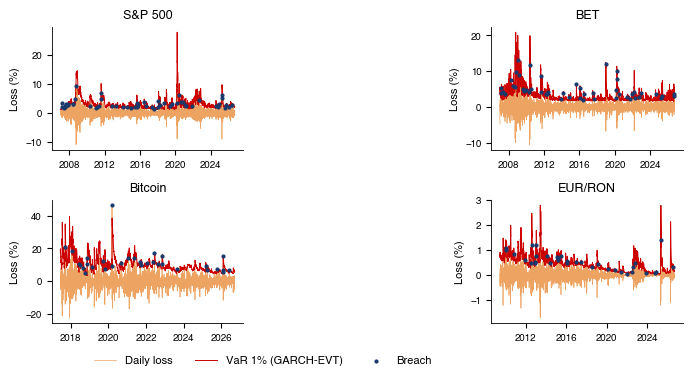

{'sp500': {'start': '2007-01-03', 'end': '2026-09-18', 'T': 4959},
 'bet': {'start': '2007-01-03', 'end': '2026-09-18', 'T': 4937},
 'btc': {'start': '2017-06-14', 'end': '2026-09-18', 'T': 3384},
 'eurron': {'start': '2009-06-11', 'end': '2026-09-18', 'T': 4352}}

In [4]:
def fig_four_assets():
    fig, axs = plt.subplots(2, 2, figsize=(7.0, 3.9), sharex=False)
    out = {}
    for ax, n in zip(axs.flat, ASSETS):
        df = fc(n)[0]['GARCH-EVT']
        ax.plot(df.index, 100 * df['L'], color=Orange, lw=0.5, alpha=0.7, label='Daily loss')
        ax.plot(df.index, 100 * df['VaR1'], color=IDAred, lw=0.7, label='VaR 1% (GARCH-EVT)')
        h = df['L'] > df['VaR1']
        ax.scatter(df.index[h], 100 * df['L'][h], s=4, color=MainBlue, zorder=3, label='Breach')
        ax.set_title(LABELS[n], fontsize=9)
        ax.set_ylabel('Loss (%)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_locator(mdates.YearLocator(4 if n != 'btc' else 2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        out[n] = dict(start=str(df.index[0].date()), end=str(df.index[-1].date()), T=len(df))
    axs[1, 0].legend(loc='upper center', bbox_to_anchor=(1.1, -0.18), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch8_four_assets')
    return out


fig_four_assets()

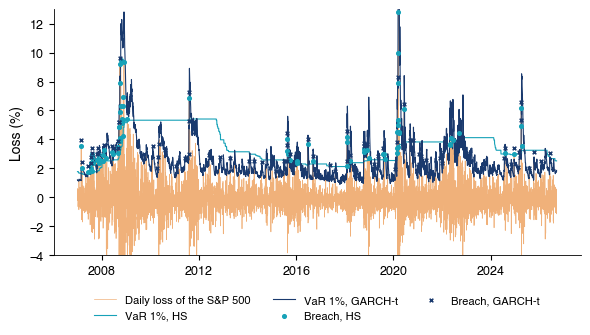

{'HS': 83, 'GARCH-t': 88}

In [5]:
def fig_sp500_var():
    F = fc('sp500')[0]
    fig, ax = plt.subplots(figsize=(6.8, 3.2))
    L = F['HS']['L']
    ax.plot(L.index, 100 * L, color=Orange, lw=0.5, alpha=0.6, label='Daily loss of the S&P 500')
    for m, ls in (('HS', '-'), ('GARCH-t', '-')):
        ax.plot(L.index, 100 * F[m]['VaR1'], color=MCOL[m], lw=0.8, ls=ls, label=f'VaR 1%, {m}')
    for m, mk in (('HS', 'o'), ('GARCH-t', 'x')):
        h = F[m]['L'] > F[m]['VaR1']
        ax.scatter(L.index[h], 100 * L[h] + (0.4 if m == 'GARCH-t' else 0), s=7, marker=mk, color=MCOL[m],
                   zorder=3, label=f'Breach, {m}')
    ax.set_ylabel('Loss (%)')
    ax.set_ylim(-4, 13)
    legend_outside_bottom(ax, ncol=3, y=-0.12)
    save_fig('ch8_sp500_var')
    return {m: int(hits('sp500', m).sum()) for m in ('HS', 'GARCH-t')}


fig_sp500_var()

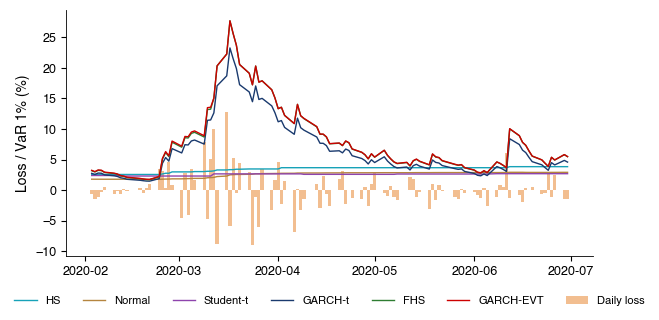

{'HS': 12,
 'Normal': 17,
 'Student-t': 17,
 'GARCH-t': 3,
 'FHS': 2,
 'GARCH-EVT': 2,
 'max_loss': 12.76521830653392,
 'max_loss_day': '2020-03-16',
 'T': 104}

In [6]:
def fig_covid_zoom():
    F = fc('sp500')[0]
    a, b = '2020-02-01', '2020-06-30'
    fig, ax = plt.subplots(figsize=(6.8, 3.2))
    L = F['HS']['L'].loc[a:b]
    ax.bar(L.index, 100 * L, color=Orange, alpha=0.5, width=1.0, label='Daily loss')
    out = {}
    for m in MODELS:
        v = F[m]['VaR1'].loc[a:b]
        ax.plot(v.index, 100 * v, color=MCOL[m], lw=1.0, label=m)
        out[m] = int((L > v).sum())
    ax.set_ylabel('Loss / VaR 1% (%)')
    legend_outside_bottom(ax, ncol=7, y=-0.12)
    save_fig('ch8_covid_zoom')
    out['max_loss'] = float(100 * L.max())
    out['max_loss_day'] = str(L.idxmax().date())
    out['T'] = len(L)
    return out


fig_covid_zoom()

## 2. Coverage and independence: Kupiec, Christoffersen, durations

- $\mathrm{LR}_{uc}=-2\ln\frac{(1-\alpha)^{T-x}\alpha^x}{(1-\hat\pi)^{T-x}\hat\pi^x}$; $\mathrm{LR}_{cc}=\mathrm{LR}_{uc}+\mathrm{LR}_{ind}$; Weibull durations with $H_0$: $b=1$.

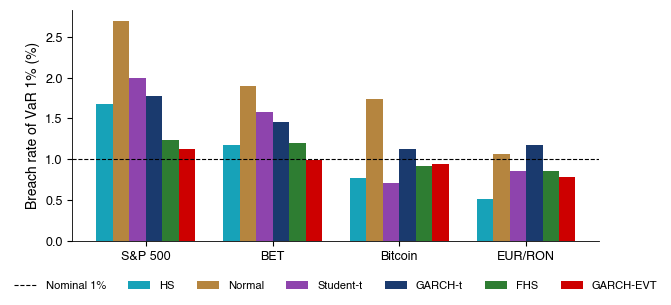

T      x    rate    LR_uc    p_uc   LR_ind   p_ind  \
sp500  HS         4959.0   83.0  0.0167  18.9064  0.0000  15.8974  0.0001   
       Normal     4959.0  134.0  0.0270  99.0453  0.0000  28.6999  0.0000   
       Student-t  4959.0   99.0  0.0200  38.5624  0.0000  17.7543  0.0000   
       GARCH-t    4959.0   88.0  0.0177  24.4257  0.0000   2.7870  0.0950   
       FHS        4959.0   61.0  0.0123   2.4709  0.1160   3.9859  0.0459   
       GARCH-EVT  4959.0   56.0  0.0113   0.8034  0.3701   4.8116  0.0283   
bet    HS         4937.0   58.0  0.0117   1.4429  0.2297   4.4465  0.0350   
       Normal     4937.0   94.0  0.0190  32.2117  0.0000  27.6146  0.0000   
       Student-t  4937.0   78.0  0.0158  14.2571  0.0002  17.6299  0.0000   
       GARCH-t    4937.0   72.0  0.0146   9.1795  0.0024   0.0025  0.9600   
       FHS        4937.0   59.0  0.0120   1.7859  0.1814   0.1119  0.7380   
       GARCH-EVT  4937.0   49.0  0.0099   0.0028  0.9577   0.4252  0.5144   
btc    HS         3384.0   26.0  0.0077   1.9939  0.1579   0.4027  0.5257   
       Normal     3384.0   59.0  0.0174  15.4649  0.0001   0.7843  0.3758   
       Student-t  3384.0   24.0  0.0071   3.2166  0.0729   1.9400  0.1637   
       GARCH-t    3384.0   38.0  0.0112   0.4968  0.4809   0.5740  0.4487   
       FHS        3384.0   31.0  0.0092   0.2477  0.6187   1.1190  0.2901   
       GARCH-EVT  3384.0   32.0  0.0095   0.1029  0.7484   1.0265  0.3110   
eurron HS         4352.0   22.0  0.0051  13.1315  0.0003   8.1160  0.0044   
       Normal     4352.0   46.0  0.0106   0.1401  0.7081  15.2070  0.0001   
       Student-t  4352.0   37.0  0.0085   1.0395  0.3079  39.8873  0.0000   
       GARCH-t    4352.0   51.0  0.0117   1.2307  0.2673   0.2311  0.6307   
       FHS        4352.0   37.0  0.0085   1.0395  0.3079   0.6347  0.4256   
       GARCH-EVT  4352.0   34.0  0.0078   2.2745  0.1315   0.5356  0.4643   

                     LR_cc    p_cc    pi01    pi11       b    LR_dur   p_dur  
sp500  HS          34.8175  0.0000  0.0154  0.0964  0.5174  104.3045  0.0000  
       Normal     127.7798  0.0000  0.0243  0.1269  0.5581  136.0419  0.0000  
       Student-t   56.3369  0.0000  0.0183  0.1010  0.5294  118.7063  0.0000  
       GARCH-t     27.2283  0.0000  0.0172  0.0455  0.9410    0.5016  0.4788  
       FHS          6.4614  0.0395  0.0118  0.0492  0.9349    0.4258  0.5141  
       GARCH-EVT    5.6176  0.0603  0.0108  0.0536  0.8848    1.3825  0.2397  
bet    HS           5.8929  0.0525  0.0113  0.0517  0.5548   48.5740  0.0000  
       Normal      59.8447  0.0000  0.0169  0.1277  0.5715   68.7116  0.0000  
       Student-t   31.8988  0.0000  0.0144  0.1026  0.5592   60.2978  0.0000  
       GARCH-t      9.1913  0.0101  0.0146  0.0139  0.9044    1.3082  0.2527  
       FHS          1.9018  0.3864  0.0119  0.0169  0.8584    2.3985  0.1214  
       GARCH-EVT    0.4278  0.8074  0.0098  0.0204  0.8673    1.6639  0.1971  
btc    HS           2.3920  0.3024  0.0077  0.0000  0.8461    1.3450  0.2462  
       Normal      15.1542  0.0005  0.0168  0.0339  0.6995   14.5214  0.0001  
       Student-t    5.1507  0.0761  0.0068  0.0417  0.5979   11.9982  0.0005  
       GARCH-t      1.0733  0.5847  0.0111  0.0263  0.9940    0.0024  0.9613  
       FHS          1.3650  0.5053  0.0089  0.0323  0.8823    0.7657  0.3816  
       GARCH-EVT    1.1284  0.5688  0.0093  0.0312  0.9121    0.4242  0.5148  
eurron HS          21.2375  0.0000  0.0046  0.0909  0.4735   26.9842  0.0000  
       Normal      15.3483  0.0005  0.0095  0.1087  0.5431   37.6081  0.0000  
       Student-t   40.9237  0.0000  0.0067  0.2162  0.4364   83.8724  0.0000  
       GARCH-t      1.4653  0.4806  0.0116  0.0196  0.9929    0.0039  0.9503  
       FHS          1.6711  0.4336  0.0086  0.0000  1.0172    0.0149  0.9027  
       GARCH-EVT    2.8057  0.2459  0.0079  0.0000  1.1287    0.6462  0.4215

In [7]:
def breach_table(col='VaR1', p=0.01):
    rows = {}
    for n in ASSETS:
        for m in MODELS:
            h = hits(n, m, col).values
            k = kupiec(h, p)
            c = christoffersen(h, p)
            d = duration_test(h)
            rows[(n, m)] = dict(T=k['T'], x=k['x'], rate=k['rate'], LR_uc=k['LR'], p_uc=k['p'], LR_ind=c['LR_ind'],
                                p_ind=c['p_ind'], LR_cc=c['LR_cc'], p_cc=c['p_cc'], pi01=c['pi01'], pi11=c['pi11'],
                                b=d['b'], LR_dur=d['LR'], p_dur=d['p'])
    return rows


def fig_breach_rates(tab):
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    w = 0.13
    for i, m in enumerate(MODELS):
        y = [100 * tab[(n, m)]['rate'] for n in ASSETS]
        ax.bar(np.arange(4) + (i - 2.5) * w, y, w, color=MCOL[m], label=m)
    ax.axhline(1.0, color='black', lw=0.8, ls='--', label='Nominal 1%')
    ax.set_xticks(range(4), [LABELS[n] for n in ASSETS])
    ax.set_ylabel('Breach rate of VaR 1% (%)')
    legend_outside_bottom(ax, ncol=7, y=-0.13)
    save_fig('ch8_breach_rates')


tab = breach_table()
fig_breach_rates(tab)
pd.DataFrame(tab).T.round(4)

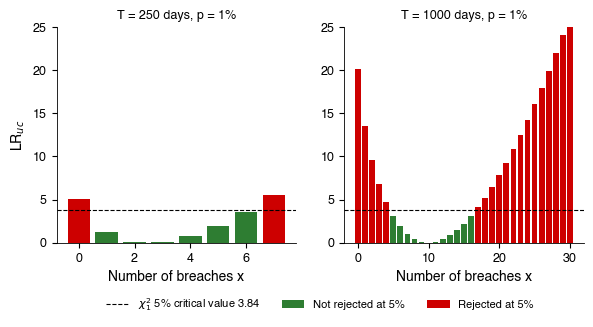

{250: {'lo': 1, 'hi': 6}, 1000: {'lo': 5, 'hi': 16}}

In [8]:
def fig_kupiec_curve():
    fig, axs = plt.subplots(1, 2, figsize=(6.8, 2.8))
    out = {}
    for ax, T in zip(axs, (250, 1000)):
        xs = np.arange(0, int(0.03 * T) + 1)
        lr = np.array([kupiec(np.r_[np.ones(x), np.zeros(T - x)], 0.01)['LR'] for x in xs])
        acc = lr < stats.chi2.ppf(0.95, 1)
        ax.bar(xs[acc], lr[acc], color=Forest, width=0.8, label='Not rejected at 5%')
        ax.bar(xs[~acc], lr[~acc], color=IDAred, width=0.8, label='Rejected at 5%')
        ax.axhline(stats.chi2.ppf(0.95, 1), color='black', ls='--', lw=0.8, label=r'$\chi^2_1$ 5% critical value 3.84')
        ax.set_title(f'T = {T} days, p = 1%', fontsize=9)
        ax.set_xlabel('Number of breaches x')
        ax.set_ylim(0, 25)
        out[T] = dict(lo=int(xs[acc].min()), hi=int(xs[acc].max()))
    axs[0].set_ylabel(r'LR$_{uc}$')
    axs[0].legend(loc='upper center', bbox_to_anchor=(1.1, -0.2), ncol=3, frameon=False)
    save_fig('ch8_kupiec_curve')
    return out


fig_kupiec_curve()

In [9]:
# Worked example: Kupiec for GARCH-t in 2008
h = hits('sp500', 'GARCH-t').loc['2008']
print(kupiec(h.values, 0.01), traffic_light(int(h.sum()), len(h)))
# Worked example: Christoffersen for HS, 2007-2010
h = hits('sp500', 'HS').loc['2007':'2010']
print(transitions(h.values), christoffersen(h.values, 0.01))

{'T': 253, 'x': 8, 'rate': np.float64(0.03162055335968379), 'LR': np.float64(7.599894081693492), 'p': np.float64(0.005837172983273007)} ('yellow', np.float64(0.9988523800270068))
{'n00': 928, 'n01': 38, 'n10': 38, 'n11': 3} {'pi01': 0.039337474120082816, 'pi11': 0.07317073170731707, 'pi': 0.0407149950347567, 'LR_ind': np.float64(0.9488096601160692), 'p_ind': np.float64(0.3300224732540265), 'LR_uc': np.float64(54.23862335314175), 'LR_cc': np.float64(55.18743301325782), 'p_cc': np.float64(1.0380091599294844e-12)}


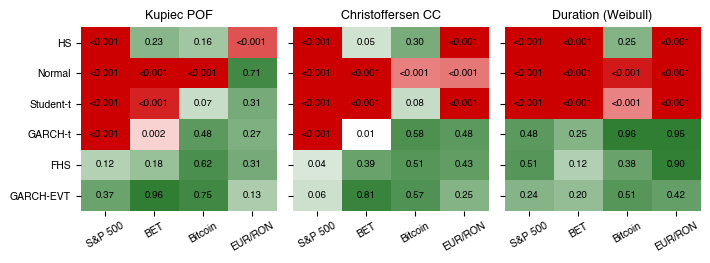

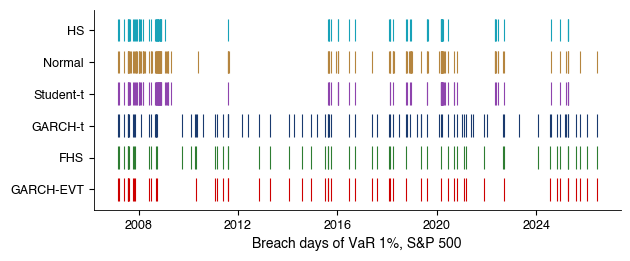

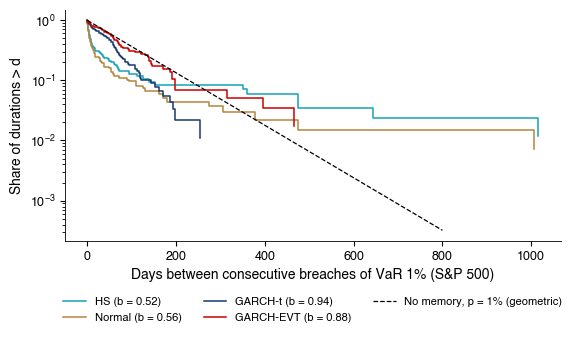

{'HS': {'n': 84, 'median': 7.0, 'share_le5': 0.44047619047619047},
 'Normal': {'n': 135, 'median': 5.0, 'share_le5': 0.5037037037037037},
 'GARCH-t': {'n': 89, 'median': 48.0, 'share_le5': 0.14606741573033707},
 'GARCH-EVT': {'n': 57, 'median': 59.0, 'share_le5': 0.12280701754385964}}

In [10]:
def fig_var_pvalues(tab):
    fig, axs = plt.subplots(1, 3, figsize=(7.2, 2.7), sharey=True)
    for ax, (key, title) in zip(axs, (('p_uc', 'Kupiec POF'), ('p_cc', 'Christoffersen CC'),
                                      ('p_dur', 'Duration (Weibull)'))):
        P = pd.DataFrame({LABELS[n]: [tab[(n, m)][key] for m in MODELS] for n in ASSETS}, index=MODELS)
        pv_heatmap(ax, P, title=title)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save_fig('ch8_var_pvalues')


def fig_breach_timeline():
    fig, ax = plt.subplots(figsize=(6.8, 2.6))
    ms = ['HS', 'Normal', 'Student-t', 'GARCH-t', 'FHS', 'GARCH-EVT']
    for i, m in enumerate(ms):
        h = hits('sp500', m)
        d = h.index[h.values == 1]
        ax.vlines(d, i - 0.35, i + 0.35, color=MCOL[m], lw=0.8)
    ax.set_yticks(range(len(ms)), ms)
    ax.invert_yaxis()
    ax.set_xlabel('Breach days of VaR 1%, S&P 500')
    save_fig('ch8_breach_timeline')
    F = fc('sp500')[0]
    by_year = {m: {str(y): int(v) for y, v in hits('sp500', m).groupby(F[m].index.year).sum().items()} for m in ms}
    return by_year


def fig_durations(tab):
    fig, ax = plt.subplots(figsize=(6.4, 3.0))
    out = {}
    for m in ('HS', 'Normal', 'GARCH-t', 'GARCH-EVT'):
        D, _, _ = durations(hits('sp500', m).values)
        Ds = np.sort(D)
        surv = 1 - np.arange(1, len(Ds) + 1) / (len(Ds) + 1)
        ax.step(Ds, surv, where='post', color=MCOL[m], label=f'{m} (b = {tab[("sp500", m)]["b"]:.2f})')
        out[m] = dict(n=len(D), median=float(np.median(D)), share_le5=float(np.mean(D <= 5)))
    d = np.linspace(1, 800, 200)
    ax.plot(d, (1 - 0.01) ** d, color='black', ls='--', lw=0.9, label='No memory, p = 1% (geometric)')
    ax.set_yscale('log')
    ax.set_xlabel('Days between consecutive breaches of VaR 1% (S&P 500)')
    ax.set_ylabel('Share of durations > d')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch8_durations')
    return out


fig_var_pvalues(tab)
fig_breach_timeline()
fig_durations(tab)

## 3. The Basel traffic light and FRTB

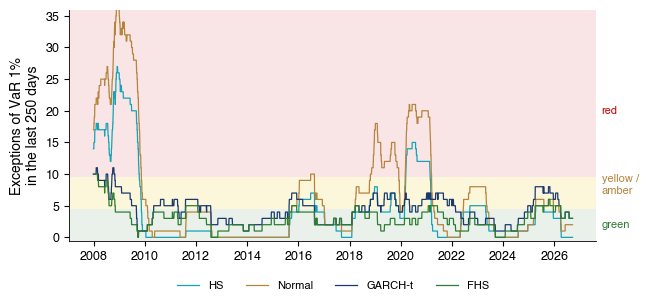

{'HS': {'max': 27,
  'max_day': '2008-12-01',
  'share_red': 0.14670912951167728,
  'share_yellow': 0.1375796178343949,
  'last': 0},
 'Normal': {'max': 37,
  'max_day': '2008-12-01',
  'share_red': 0.2227176220806794,
  'share_yellow': 0.21613588110403398,
  'last': 2},
 'GARCH-t': {'max': 11,
  'max_day': '2008-02-05',
  'share_red': 0.019957537154989383,
  'share_yellow': 0.4656050955414013,
  'last': 3},
 'FHS': {'max': 10,
  'max_day': '2007-12-28',
  'share_red': 0.008067940552016985,
  'share_yellow': 0.14713375796178343,
  'last': 3}}

In [11]:
def rolling_exceptions(name, model, col='VaR1', n=250):
    return hits(name, model, col).rolling(n).sum().dropna()


def fig_traffic_light():
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    ax.axhspan(-0.5, 4.5, color=Forest, alpha=0.10, lw=0)
    ax.axhspan(4.5, 9.5, color='#F1C40F', alpha=0.15, lw=0)
    ax.axhspan(9.5, 40, color=IDAred, alpha=0.10, lw=0)
    out = {}
    for m in ('HS', 'Normal', 'GARCH-t', 'FHS'):
        x = rolling_exceptions('sp500', m)
        ax.plot(x.index, x, color=MCOL[m], lw=0.9, label=m)
        out[m] = dict(max=int(x.max()), max_day=str(x.idxmax().date()), share_red=float(np.mean(x >= 10)),
                      share_yellow=float(np.mean((x >= 5) & (x <= 9))), last=int(x.iloc[-1]))
    ax.text(1.01, 2 / 36.5, 'green', color=Forest, fontsize=8, transform=ax.transAxes)
    ax.text(1.01, 7.5 / 36.5, 'yellow /\namber', color=Amber, fontsize=8, transform=ax.transAxes)
    ax.text(1.01, 20 / 36.5, 'red', color=IDAred, fontsize=8, transform=ax.transAxes)
    ax.set_ylim(-0.5, 36)
    ax.set_ylabel('Exceptions of VaR 1%\nin the last 250 days')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    save_fig('ch8_traffic_light')
    return out


fig_traffic_light()

In [12]:
# Binomial probabilities behind the zones (250 days, VaR 1%)
pd.Series({k: stats.binom.cdf(k, 250, 0.01) for k in range(11)}).round(4)

0     0.0811
1     0.2858
2     0.5432
3     0.7581
4     0.8922
5     0.9588
6     0.9863
7     0.9960
8     0.9989
9     0.9997
10    0.9999
dtype: float64

## 4. Backtesting ES: McNeil–Frey, Acerbi–Szekely, Du–Escanciano

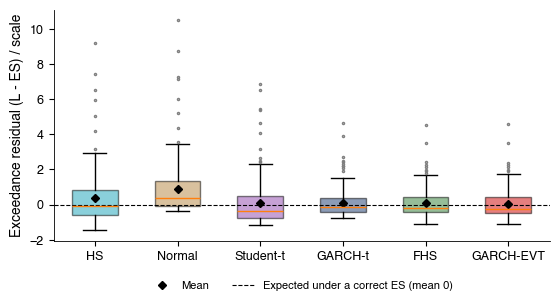

{'HS': 0.3634806717134465,
 'Normal': 0.8747169184808322,
 'Student-t': 0.08160102576426573,
 'GARCH-t': 0.10627145203154999,
 'FHS': 0.09317088408363747,
 'GARCH-EVT': 0.0451935694344184}

In [13]:
def fig_mf_residuals():
    fig, ax = plt.subplots(figsize=(6.4, 3.0))
    data, out = [], {}
    for m in MODELS:
        df = fc('sp500')[0][m]
        h = df['L'] > df['VaR2.5']
        e = ((df['L'] - df['ES2.5']) / df['scale'])[h]
        data.append(e.values)
        out[m] = float(e.mean())
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=True,
                    flierprops=dict(marker='.', markersize=3, markeredgecolor=Gray))
    for b, m in zip(bp['boxes'], MODELS):
        b.set_facecolor(MCOL[m]); b.set_alpha(0.5)
    for i, m in enumerate(MODELS):
        ax.plot(i + 1, out[m], 'D', color='black', ms=4, label='Mean' if i == 0 else None)
    ax.axhline(0, color='black', lw=0.8, ls='--', label='Expected under a correct ES (mean 0)')
    ax.set_xticks(range(1, 7), MODELS)
    ax.set_ylabel('Exceedance residual (L - ES) / scale')
    legend_outside_bottom(ax, ncol=2, y=-0.13)
    save_fig('ch8_mf_residuals')
    return out


fig_mf_residuals()

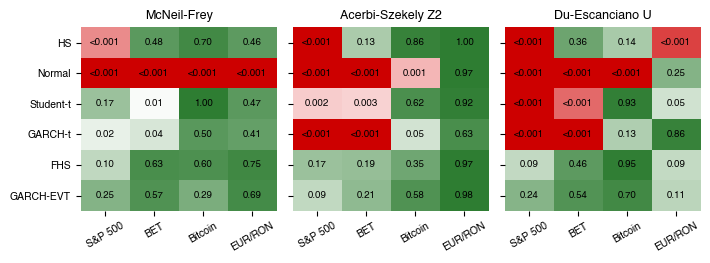

n_hit  MF_mean   MF_t   MF_p     Z1     p1     Z2     p2  \
sp500  HS         156.0    0.363  2.879  0.001 -0.117  0.000 -0.405  0.000   
       Normal     196.0    0.875  7.882  0.000 -0.378  0.000 -1.179  0.000   
       Student-t  208.0    0.082  0.903  0.173 -0.027  0.272 -0.723  0.002   
       GARCH-t    192.0    0.106  1.797  0.023 -0.045  0.062 -0.618  0.000   
       FHS        130.0    0.093  1.214  0.096 -0.041  0.064 -0.091  0.172   
       GARCH-EVT  136.0    0.045  0.608  0.246 -0.023  0.162 -0.123  0.090   
bet    HS         136.0   -0.001 -0.006  0.478 -0.007  0.434 -0.110  0.134   
       Normal     153.0    0.760  5.708  0.000 -0.329  0.000 -0.648  0.000   
       Student-t  154.0    0.263  1.870  0.012 -0.091  0.056 -0.362  0.002   
       GARCH-t    169.0    0.138  1.408  0.041 -0.052  0.048 -0.441  0.000   
       FHS        136.0   -0.056 -0.479  0.633  0.014  0.632 -0.086  0.188   
       GARCH-EVT  134.0   -0.035 -0.293  0.575  0.008  0.564 -0.077  0.210   
btc    HS          76.0   -0.101 -0.693  0.701  0.028  0.744  0.127  0.863   
       Normal      96.0    0.458  3.849  0.000 -0.201  0.000 -0.362  0.001   
       Student-t  100.0   -0.472 -5.643  1.000  0.200  0.998  0.054  0.624   
       GARCH-t    103.0   -0.012 -0.073  0.502  0.001  0.470 -0.216  0.050   
       FHS         90.0   -0.067 -0.385  0.599  0.019  0.645 -0.044  0.346   
       GARCH-EVT   80.0    0.081  0.432  0.290 -0.028  0.248  0.028  0.581   
eurron HS          71.0   -0.001 -0.005  0.457 -0.002  0.472  0.346  1.000   
       Normal      70.0    0.660  3.441  0.000 -0.288  0.000  0.171  0.972   
       Student-t   90.0   -0.011 -0.041  0.472  0.005  0.445  0.177  0.920   
       GARCH-t    104.0    0.015  0.150  0.408 -0.005  0.428  0.039  0.630   
       FHS         92.0   -0.089 -0.878  0.749  0.027  0.832  0.177  0.968   
       GARCH-EVT   90.0   -0.071 -0.685  0.694  0.020  0.723  0.189  0.976   

                  Z2_crit    U_ES    p_U     C_ES    p_C  meanH  
sp500  HS          -0.154   4.399  0.000  626.630  0.000  0.018  
       Normal      -0.146  12.695  0.000  561.955  0.000  0.029  
       Student-t   -0.194   8.155  0.000  651.242  0.000  0.023  
       GARCH-t     -0.151   6.843  0.000   17.835  0.003  0.021  
       FHS         -0.152   1.704  0.088   21.747  0.001  0.015  
       GARCH-EVT   -0.149   1.165  0.244   18.782  0.002  0.014  
bet    HS          -0.160   0.914  0.361  359.895  0.000  0.014  
       Normal      -0.145   6.417  0.000  400.608  0.000  0.021  
       Student-t   -0.174   3.553  0.000  486.488  0.000  0.017  
       GARCH-t     -0.156   4.700  0.000    8.054  0.153  0.019  
       FHS         -0.162   0.744  0.457    5.242  0.387  0.013  
       GARCH-EVT   -0.157   0.605  0.545    5.306  0.380  0.013  
btc    HS          -0.202  -1.464  0.143   38.057  0.000  0.010  
       Normal      -0.189   3.920  0.000   58.222  0.000  0.019  
       Student-t   -0.238  -0.089  0.929   78.798  0.000  0.012  
       GARCH-t     -0.215   1.532  0.126    8.048  0.154  0.015  
       FHS         -0.204   0.057  0.955   10.714  0.057  0.013  
       GARCH-EVT   -0.207  -0.379  0.705   11.353  0.045  0.012  
eurron HS          -0.173  -3.681  0.000  193.769  0.000  0.007  
       Normal      -0.167  -1.147  0.252  160.545  0.000  0.011  
       Student-t   -0.235  -1.932  0.053  465.642  0.000  0.010  
       GARCH-t     -0.183   0.178  0.858    7.247  0.203  0.013  
       FHS         -0.172  -1.717  0.086    4.021  0.546  0.010  
       GARCH-EVT   -0.174  -1.612  0.107    4.426  0.490  0.010

In [14]:
def es_table():
    rows = {}
    for n in ASSETS:
        F, tails = fc(n)
        for m in MODELS:
            df = F[m]
            mf = mcneil_frey(df['L'].values, df['VaR2.5'].values, df['ES2.5'].values, df['scale'].values)
            z = z_pvalues(df, m, tails, M=2000)
            de = du_escanciano(df['pit'].values)
            rows[(n, m)] = dict(n_hit=mf['n'], MF_mean=mf['mean'], MF_t=mf['t'], MF_p=mf['p'], Z1=z['Z1'], p1=z['p1'],
                                Z2=z['Z2'], p2=z['p2'], Z2_crit=z['crit2'], U_ES=de['U'], p_U=de['pU'], C_ES=de['C'],
                                p_C=de['pC'], meanH=de['meanH'])
    return rows


def fig_es_pvalues(tab):
    fig, axs = plt.subplots(1, 3, figsize=(7.2, 2.7), sharey=True)
    for ax, (key, title) in zip(axs, (('MF_p', 'McNeil-Frey'), ('p2', 'Acerbi-Szekely Z2'),
                                      ('p_U', 'Du-Escanciano U'))):
        P = pd.DataFrame({LABELS[n]: [tab[(n, m)][key] for m in MODELS] for n in ASSETS}, index=MODELS)
        pv_heatmap(ax, P, title=title)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save_fig('ch8_es_pvalues')


est = es_table()
fig_es_pvalues(est)
pd.DataFrame(est).T.round(3)

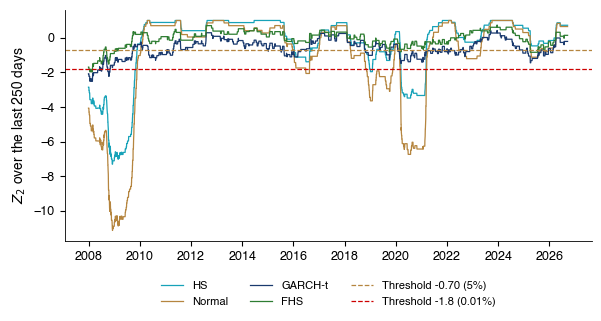

{'HS': {'min': -7.303093240046394,
  'min_day': '2008-12-01',
  'share_below07': 0.24140127388535032,
  'share_below18': 0.15753715498938428,
  'last': 0.7227350864830077},
 'Normal': {'min': -11.131898692281839,
  'min_day': '2008-12-04',
  'share_below07': 0.3813163481953291,
  'share_below18': 0.21910828025477708,
  'last': 0.6489165637203147},
 'GARCH-t': {'min': -2.5172769400704724,
  'min_day': '2008-02-05',
  'share_below07': 0.3955414012738854,
  'share_below18': 0.030360934182590234,
  'last': -0.20991822652841496},
 'FHS': {'min': -1.968533428057353,
  'min_day': '2008-01-17',
  'share_below07': 0.07728237791932059,
  'share_below18': 0.007218683651804671,
  'last': 0.14202429740283795}}

In [15]:
def rolling_z2(name, model, n=250):
    df = fc(name)[0][model]
    L, v, e = df['L'].values, df['VaR2.5'].values, df['ES2.5'].values
    term = np.where(L > v, L / e, 0.0)
    z2 = 1 - pd.Series(term, index=df.index).rolling(n).sum() / (n * A_ES)
    return z2.dropna()


def fig_z2_rolling():
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    out = {}
    for m in ('HS', 'Normal', 'GARCH-t', 'FHS'):
        z = rolling_z2('sp500', m)
        ax.plot(z.index, z, color=MCOL[m], lw=0.9, label=m)
        out[m] = dict(min=float(z.min()), min_day=str(z.idxmin().date()), share_below07=float(np.mean(z < -0.7)),
                      share_below18=float(np.mean(z < -1.8)), last=float(z.iloc[-1]))
    ax.axhline(-0.70, color=Amber, ls='--', lw=0.9, label='Threshold -0.70 (5%)')
    ax.axhline(-1.8, color=IDAred, ls='--', lw=0.9, label='Threshold -1.8 (0.01%)')
    ax.set_ylabel(r'$Z_2$ over the last 250 days')
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    save_fig('ch8_z2_rolling')
    return out


fig_z2_rolling()

## 5. Elicitability: pinball and FZ0 losses

- $\mathrm{FZ0}(v,e;L)=\frac{\mathbf{1}\{L>v\}(L-v)}{\alpha e}+\frac{v}{e}+\ln e-1$.

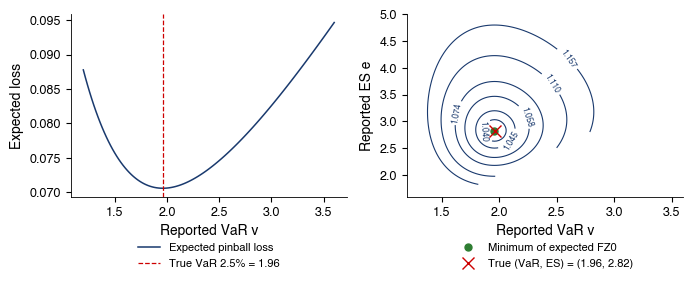

{'nu': 4,
 'q': np.float64(1.963243161477561),
 'es': np.float64(2.823871251815408),
 'v_min': 1.96,
 'fz_v': 1.96,
 'fz_e': 2.8183333333333334}

In [16]:
def fig_elicitability(nu=4, a=0.025, n=2_000_000, seed=3):
    rng = np.random.default_rng(seed)
    L = rng.standard_t(nu, n) * np.sqrt((nu - 2) / nu)
    q_true, es_true = t_std_q(nu, a), t_std_es(nu, a)
    vs = np.linspace(1.2, 3.6, 121)
    m_plus = np.array([np.mean(np.maximum(L - v, 0)) for v in vs])      # E[(L - v)+]
    pin = m_plus - a * (np.mean(L) - vs)                                 # E[(1{L>v} - a)(L - v)]
    es_grid = np.linspace(1.6, 5.0, 121)
    V, E = np.meshgrid(vs, es_grid)
    FZ = np.interp(V, vs, m_plus) / (a * E) + V / E + np.log(E) - 1
    FZ = np.where(E >= V, FZ, np.nan)
    fig, axs = plt.subplots(1, 2, figsize=(7.0, 3.0))
    ax = axs[0]
    ax.plot(vs, pin, color=MainBlue, label='Expected pinball loss')
    ax.axvline(q_true, color=IDAred, ls='--', lw=0.9, label=f'True VaR 2.5% = {q_true:.2f}')
    ax.set_xlabel('Reported VaR v')
    ax.set_ylabel('Expected loss')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    ax = axs[1]
    cs = ax.contour(V, E, FZ, levels=np.nanquantile(FZ, [0.01, 0.03, 0.08, 0.15, 0.3, 0.5]), colors=MainBlue,
                    linewidths=0.8)
    ax.clabel(cs, fontsize=6, fmt='%.3f')
    i = np.nanargmin(FZ)
    ax.plot(V.flat[i], E.flat[i], 'o', color=Forest, ms=5, label='Minimum of expected FZ0')
    ax.plot(q_true, es_true, 'x', color=IDAred, ms=8, label=f'True (VaR, ES) = ({q_true:.2f}, {es_true:.2f})')
    ax.set_xlabel('Reported VaR v')
    ax.set_ylabel('Reported ES e')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch8_elicitability')
    return dict(nu=nu, q=q_true, es=es_true, v_min=float(vs[np.argmin(pin)]), fz_v=float(V.flat[i]),
                fz_e=float(E.flat[i]))


fig_elicitability()

## 6. Comparative backtesting: Diebold–Mariano and the model confidence set

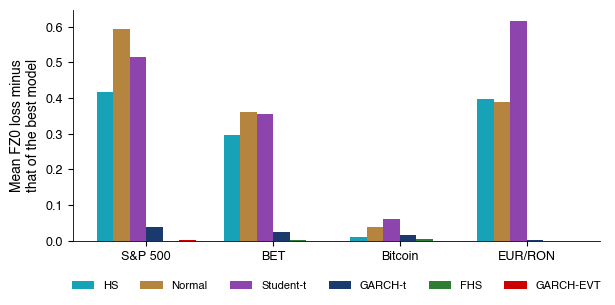

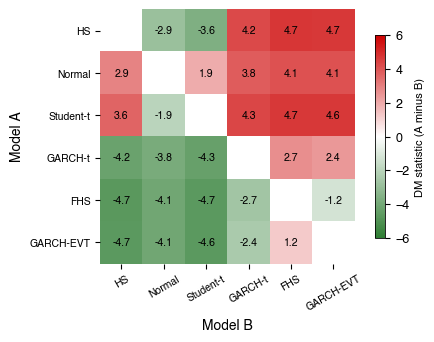

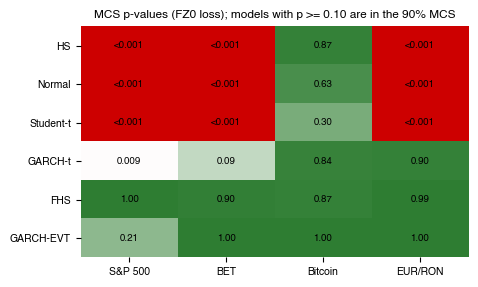

,sp500,bet,btc,eurron
HS,0.000,0.000,0.870,0.000
Normal,0.000,0.000,0.634,0.000
Student-t,0.000,0.000,0.303,0.000
GARCH-t,0.009,0.087,0.839,0.895
FHS,1.000,0.901,0.870,0.995
GARCH-EVT,0.214,1.000,1.000,1.000


In [17]:
def fz_losses(name):
    F = fc(name)[0]
    return pd.DataFrame({m: fz0(F[m]['L'].values, F[m]['VaR2.5'].values, F[m]['ES2.5'].values)
                         for m in MODELS}, index=F['HS'].index)


def fz_table():
    out = {}
    for n in ASSETS:
        Lf = fz_losses(n)
        best = Lf.mean().idxmin()
        dm = {m: diebold_mariano(Lf[m], Lf[best]) for m in MODELS if m != best}
        mc = mcs(Lf)
        out[n] = dict(mean={m: float(v) for m, v in Lf.mean().items()}, best=best,
                      dm={m: dict(DM=d['DM'], p=d['p'], dbar=d['dbar']) for m, d in dm.items()},
                      mcs={m: float(v) for m, v in mc.items()},
                      pin={m: float(pinball(fc(n)[0][m]['L'].values, fc(n)[0][m]['VaR1'].values, 0.01).mean())
                           for m in MODELS})
    return out


def fig_fz0(tab):
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    w = 0.13
    for i, m in enumerate(MODELS):
        y = [tab[n]['mean'][m] - tab[n]['mean'][tab[n]['best']] for n in ASSETS]
        ax.bar(np.arange(4) + (i - 2.5) * w, y, w, color=MCOL[m], label=m)
    ax.set_xticks(range(4), [LABELS[n] for n in ASSETS])
    ax.set_ylabel('Mean FZ0 loss minus\nthat of the best model')
    legend_outside_bottom(ax, ncol=6, y=-0.13)
    save_fig('ch8_fz0')


def fig_dm_matrix(name='sp500'):
    Lf = fz_losses(name)
    D = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
    for a in MODELS:
        for b in MODELS:
            D.loc[a, b] = np.nan if a == b else diebold_mariano(Lf[a], Lf[b])['DM']
    fig, ax = plt.subplots(figsize=(5.4, 3.3))
    im = ax.imshow(D.values.astype(float), cmap=LinearSegmentedColormap.from_list('dm', [Forest, '#FFFFFF', IDAred]),
                   vmin=-6, vmax=6)
    for i in range(6):
        for j in range(6):
            if i != j:
                ax.text(j, i, f'{D.values[i, j]:.1f}', ha='center', va='center', fontsize=7.5)
    ax.set_xticks(range(6), MODELS, rotation=30, fontsize=7.5)
    ax.set_yticks(range(6), MODELS, fontsize=7.5)
    ax.set_xlabel('Model B')
    ax.set_ylabel('Model A')
    cb = plt.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label('DM statistic (A minus B)', fontsize=8)
    for s in ax.spines.values():
        s.set_visible(False)
    save_fig('ch8_dm_matrix')
    return {f'{a}|{b}': float(D.loc[a, b]) for a in MODELS for b in MODELS if a != b}


def fig_mcs(tab):
    P = pd.DataFrame({LABELS[n]: [tab[n]['mcs'][m] for m in MODELS] for n in ASSETS}, index=MODELS)
    fig, ax = plt.subplots(figsize=(5.0, 3.0))
    pv_heatmap(ax, P)
    ax.set_title('MCS p-values (FZ0 loss); models with p >= 0.10 are in the 90% MCS', fontsize=8.5)
    save_fig('ch8_mcs')


fz = fz_table()
fig_fz0(fz)
fig_dm_matrix()
fig_mcs(fz)
pd.DataFrame({n: fz[n]['mcs'] for n in fz}).round(3)

## 7. Conformal prediction for tail risk

- Split conformal: $\mathrm{VaR}_t=\hat\sigma_t\,s_{(k)}$, $k=\lceil(n+1)(1-\alpha)\rceil$.
- ACI: $\alpha_{t+1}=\alpha_t+\gamma(\alpha-\mathrm{err}_t)$.

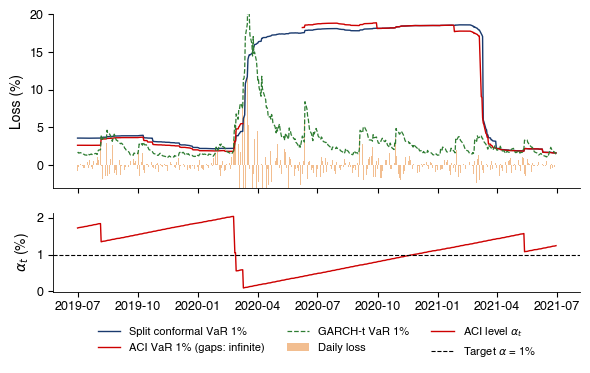

{'covid_split': 6,
 'covid_aci': 4,
 'covid_T': 50,
 'covid_inf': 37,
 'alpha_min': 0.0009000000000003068}

In [18]:
def fig_conformal_path():
    r = load_returns('sp500')
    c = conformal_var(r, a=0.01).loc['2019-07-01':'2021-06-30']
    g = fc('sp500')[0]['GARCH-t']['VaR1'].loc[c.index]
    fig, axs = plt.subplots(2, 1, figsize=(6.8, 3.6), sharex=True, gridspec_kw=dict(height_ratios=[2.2, 1]))
    ax = axs[0]
    ax.bar(c.index, 100 * c['L'], color=Orange, alpha=0.5, width=1.0, label='Daily loss')
    ax.plot(c.index, 100 * c['VaR_split'], color=MainBlue, lw=1.0, label='Split conformal VaR 1%')
    va = np.where(np.isinf(c['VaR_aci']), np.nan, c['VaR_aci'])
    ax.plot(c.index, 100 * va, color=IDAred, lw=1.0, label='ACI VaR 1% (gaps: infinite)')
    ax.plot(c.index, 100 * g, color=Forest, lw=0.9, ls='--', label='GARCH-t VaR 1%')
    ax.set_ylabel('Loss (%)')
    ax.set_ylim(-3, 20)
    ax = axs[1]
    ax.plot(c.index, 100 * c['alpha_t'], color=IDAred, lw=1.0, label=r'ACI level $\alpha_t$')
    ax.axhline(1.0, color='black', ls='--', lw=0.8, label=r'Target $\alpha$ = 1%')
    ax.set_ylabel(r'$\alpha_t$ (%)')
    h1, l1 = axs[0].get_legend_handles_labels()
    h2, l2 = axs[1].get_legend_handles_labels()
    axs[1].legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=False)
    save_fig('ch8_conformal_path')
    cc = c.loc['2020-02-20':'2020-04-30']
    return dict(covid_split=int((cc['L'] > cc['VaR_split']).sum()), covid_aci=int((cc['L'] > cc['VaR_aci']).sum()),
                covid_T=len(cc), covid_inf=int(np.isinf(cc['VaR_aci']).sum()), alpha_min=float(c['alpha_t'].min()))


fig_conformal_path()

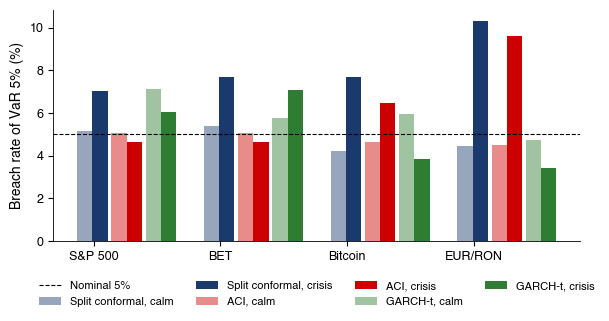

,sp500,bet,btc,eurron
split,"[0.0534381931841097, 0.05153484203450594, 0.07...","[0.056309499696171765, 0.05401755570560432, 0....","[0.04580378250591016, 0.042364532019704436, 0....","[0.050551470588235295, 0.04468845760980592, 0...."
aci,"[0.05021173623714459, 0.050638583912166704, 0....","[0.050435487137938016, 0.050866531622777406, 0...","[0.048167848699763594, 0.04630541871921182, 0....","[0.05032169117647059, 0.04519918283963228, 0.0..."
garch,"[0.07017543859649122, 0.07125252072596908, 0.0...","[0.0591452298966984, 0.057843799234751296, 0.0...","[0.057328605200945626, 0.059441707717569785, 0...","[0.046185661764705885, 0.047497446373850866, 0..."


In [19]:
def conformal_table(a=0.01):
    out = {}
    for n in ASSETS:
        r = load_returns(n)
        c = conformal_var(r, a=a).loc[fc(n)[0]['HS'].index[0]:]
        reg = regimes(r, c.index)
        g = fc(n)[0]['GARCH-t'].reindex(c.index)
        col = {0.01: 'VaR1', 0.05: 'VaR5', 0.025: 'VaR2.5'}[a]
        hs, ha, hg = c['L'] > c['VaR_split'], c['L'] > c['VaR_aci'], g['L'] > g[col]
        out[n] = dict(T=len(c), n_crisis=int(reg.sum()),
                      split=[float(hs.mean()), float(hs[~reg].mean()), float(hs[reg].mean())],
                      aci=[float(ha.mean()), float(ha[~reg].mean()), float(ha[reg].mean())],
                      garch=[float(hg.mean()), float(hg[~reg].mean()), float(hg[reg].mean())],
                      inf_share=float(np.isinf(c['VaR_aci']).mean()),
                      kup_split=kupiec(hs.values, a)['p'], kup_aci=kupiec(ha.values, a)['p'])
    return out


def fig_conformal_regimes(tab):
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    labels, x = [], 0
    for n in ASSETS:
        for j, (k, col) in enumerate((('split', MainBlue), ('aci', IDAred), ('garch', Forest))):
            ax.bar(x + j * 0.27 - 0.27, 100 * tab[n][k][1], 0.12, color=col, alpha=0.45,
                   label={'split': 'Split conformal', 'aci': 'ACI', 'garch': 'GARCH-t'}[k] + ', calm' if n == 'sp500' else None)
            ax.bar(x + j * 0.27 - 0.27 + 0.12, 100 * tab[n][k][2], 0.12, color=col,
                   label={'split': 'Split conformal', 'aci': 'ACI', 'garch': 'GARCH-t'}[k] + ', crisis' if n == 'sp500' else None)
        labels.append(LABELS[n])
        x += 1
    ax.axhline(5.0, color='black', ls='--', lw=0.8, label='Nominal 5%')
    ax.set_xticks(np.arange(4) - 0.2, labels)
    ax.set_ylabel('Breach rate of VaR 5% (%)')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    save_fig('ch8_conformal_regimes')


cf = conformal_table(0.05)
fig_conformal_regimes(cf)
pd.DataFrame({n: {k: v for k, v in d.items() if k in ('split', 'aci', 'garch')} for n, d in cf.items()})

## Conclusions

- Unconditional models (HS, Normal, Student-t) produce clustered breaches that duration tests detect.
- The Basel traffic light is a Binomial test on 250 days; FRTB keeps it and adds ES-based capital.
- ES tests need the whole forecast distribution; FZ0 ranks (VaR, ES) forecasts consistently.
- FHS and GARCH-EVT pass the tests and stay in the model confidence set in all four markets.
- Conformal VaR guarantees only marginal coverage: it breaches more after turbulent periods.